# Thematic Clustering
**Cluster Definitions**
1. Cluster 1: Economic Optimization
- Focus: The primary goal is financial.
- Inclusion Criteria: The paper's main contribution is a method to minimize charging costs, maximize revenue for a charging station operator, or participate in an electricity market (e.g., through bidding strategies). The core problem is framed in economic terms.

2. Cluster 2: Grid Stability & Services
- Focus: The primary goal is the physical health of the power grid.
- Inclusion Criteria: The paper's main contribution is a method to provide grid services like frequency regulation, voltage control, or congestion management. The core problem is framed in terms of electrical engineering and grid constraints.

3. Cluster 3: Causal Discovery & Modeling
- Focus: The primary goal is theoretical or algorithmic development in causality.
- Inclusion Criteria: The paper's main contribution is a new algorithm or framework for learning causal relationships from data, building causal graphs, or explicitly incorporating a known causal model into an RL agent's decision-making process.

4. Cluster 4: Counterfactual Policy Evaluation
- Focus: The primary goal is evaluating "what if" scenarios for safety and effectiveness.
- Inclusion Criteria: The paper's main contribution is a method for off-policy evaluation, counterfactual reasoning, or estimating the effect of a policy different from the one that collected the data. This is about validating a policy's impact.

5. Cluster 5: Explainability & Interpretability
- Focus: The primary goal is making "black box" models transparent.
- Inclusion Criteria: The paper's main contribution is a technique for explaining an RL agent's policy, visualizing its decision-making process, or building an inherently interpretable model.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google import genai
from google.genai import types
import os
from dotenv import load_dotenv 
from tqdm import tqdm
import time

## 1. Load the Completed Qualitative Analysis Sheet

In [12]:
try:
    analysis_df = pd.read_csv('./data/processed/qualitative_analysis_sheet.csv')
    print(f"Successfully loaded {len(analysis_df)} papers from the completed analysis sheet.")
except FileNotFoundError:
    print("Error: Make sure 'qualitative_analysis_sheet.csv' is in the 'data/processed/' directory.")

Successfully loaded 75 papers from the completed analysis sheet.


## 2. Define Gemini Classification Function

In [13]:
# --- Configure Gemini API via Vertex AI ---
load_dotenv()
# NOTE: Ensure your .env file has GCP_PROJECT_ID and GCP_LOCATION
PROJECT_ID = os.getenv("GCP_PROJECT_ID")
LOCATION = os.getenv("GCP_LOCATION")

# It initializes the Vertex AI client.
client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

# It defines the model to be used.
model = "gemini-2.5-pro"

# It configures the generation settings for reproducibility.
generate_content_config = types.GenerateContentConfig(
  # CRITICAL: Temperature is set to 0 for deterministic and reproducible results.
  temperature = 0,
  top_p = 0.95,
  max_output_tokens = 8192,
  seed=73,
  safety_settings = [
      types.SafetySetting(category="HARM_CATEGORY_HATE_SPEECH", threshold="BLOCK_NONE"),
      types.SafetySetting(category="HARM_CATEGORY_DANGEROUS_CONTENT", threshold="BLOCK_NONE"),
      types.SafetySetting(category="HARM_CATEGORY_SEXUALLY_EXPLICIT", threshold="BLOCK_NONE"),
      types.SafetySetting(category="HARM_CATEGORY_HARASSMENT", threshold="BLOCK_NONE")
  ],
)

print(f"Setup complete. Gemini model '{model}' is configured via Vertex AI.")

Setup complete. Gemini model 'gemini-2.5-pro' is configured via Vertex AI.


In [14]:
CLUSTER_DEFINITIONS = """
1.  **Economic Optimization:** Focuses on financial goals like minimizing charging cost, maximizing revenue, or bidding in electricity markets.
2.  **Grid Stability & Services:** Focuses on the physical health of the power grid, providing services like frequency regulation, voltage control, or congestion management.
3.  **Causal Discovery & Modeling:** Focuses on the theory of learning or using causal graphs and models within a Reinforcement Learning framework.
4.  **Counterfactual Policy Evaluation:** Focuses on evaluating "what if" scenarios to assess a policy's safety, effectiveness, or impact.
5.  **Explainability & Interpretability:** Focuses on techniques to make "black box" AI/RL models transparent and understandable.
"""

def classify_paper_with_gemini(row):
    """
    Asks Gemini to classify a paper into one of five thematic clusters.
    """
    # We combine multiple fields to give the model rich context.
    title = row['Title']
    contribution = row['Key_Contribution']
    synthesis = row['Researcher_Synthesis_Connections']
    
    prompt = f"""
    You are an expert research analyst. Your task is to classify an academic paper into one of five thematic clusters based on its title, key contribution, and a researcher's notes.
    
    Here are the cluster definitions:
    {CLUSTER_DEFINITIONS}

    Now, analyze the following paper and choose the SINGLE best-fitting cluster.
    
    **Title:** "{title}"
    **Key Contribution:** "{contribution}"
    **Researcher's Notes:** "{synthesis}"

    Respond with ONLY the name of the chosen cluster (e.g., "Economic Optimization"). Do not add any other text or explanation.
    """
    
    try:
        response = client.models.generate_content(
            model=model,
            contents=prompt,
            config=generate_content_config,
        )
        # The response should be clean, just the cluster name.
        return response.text.strip()
    except Exception as e:
        print(f"An API error occurred: {e}")
        return "AI_Error"

## 3. Run Classification

In [19]:
if not analysis_df.empty:
    print("\nStarting thematic classification with Gemini...")
    
    ai_classifications = []
    # It iterates through each paper and calls the classification function.
    for index, row in tqdm(analysis_df.iterrows(), total=len(analysis_df)):
        cluster = classify_paper_with_gemini(row)
        ai_classifications.append(cluster)
        time.sleep(1) # A brief pause to respect API rate limits

    # Create a new DataFrame for the results
    classification_results_df = pd.DataFrame({
        'paperId': analysis_df['paperId'],
        'Title': analysis_df['Title'],
        'AI_Cluster': ai_classifications,
        'Manual_Cluster': ''
    })
    
    # Save the results to a new CSV for comparison
    classification_results_df.to_csv('./data/processed/thematic_classification_results.csv', index=False)
    
    print("\nClassification complete!")
    print("Results saved to 'thematic_classification_results.csv'.")
    print("Please open the file and fill in the 'Manual_Cluster' column.")
    
    display(classification_results_df.head())


Starting thematic classification with Gemini...


100%|██████████| 75/75 [16:34<00:00, 13.26s/it]


Classification complete!
Results saved to 'thematic_classification_results.csv'.
Please open the file and fill in the 'Manual_Cluster' column.


,paperId,Title,AI_Cluster,Manual_Cluster
0,59021ecd3fd15c59b8b774c87ae974c9fffe9fa5,Model-Free Real-Time EV Charging Scheduling Ba...,Economic Optimization,
1,648ea87fe7f99ca8ea5090cb1ba40242299ef4c4,Reinforcement learning for demand response: A ...,Economic Optimization,
2,7158277c0361f15a7c67621f5940c4208c9c46ce,Optimizing renewable energy systems through ar...,Economic Optimization,
3,cd3c9cba90f778ada660a462d58573756c60fb27,Reinforcement Learning-Based Plug-in Electric ...,Economic Optimization,
4,745a134eca192982e8e0c16d6f36cfe24f9bdd08,"Woulda, Coulda, Shoulda: Counterfactually-Guid...",Counterfactual Policy Evaluation,



--- Distribution of Papers Across Thematic Clusters ---
AI_Cluster
Economic Optimization                28
Grid Stability & Services            18
Causal Discovery & Modeling          16
Counterfactual Policy Evaluation      7
Explainability & Interpretability     6
Name: count, dtype: int64


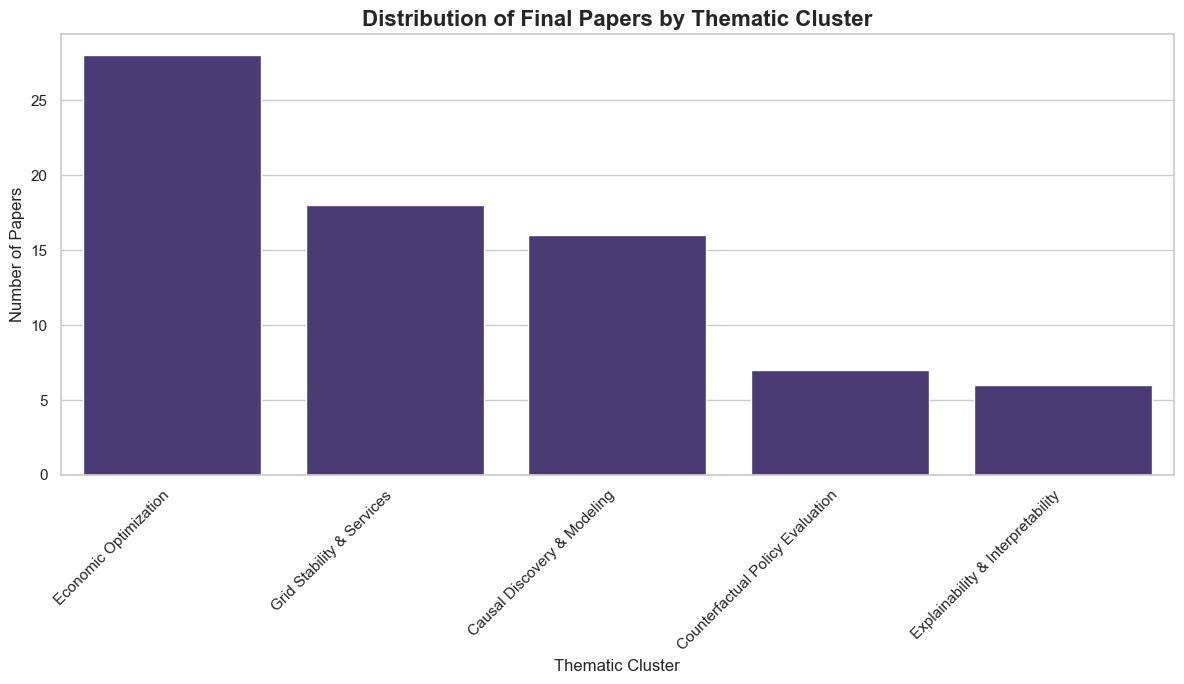

In [21]:
if not classification_results_df.empty:
    sns.set_theme(style="whitegrid", palette="viridis")

    cluster_distribution = classification_results_df['AI_Cluster'].value_counts()

    print("\n--- Distribution of Papers Across Thematic Clusters ---")
    print(cluster_distribution)
    
    # It creates a high-quality bar chart for use in the final essay.
    plt.figure(figsize=(12, 7))
    sns.barplot(x=cluster_distribution.index, y=cluster_distribution.values)
    
    plt.title('Distribution of Final Papers by Thematic Cluster', fontsize=16, weight='bold')
    plt.xlabel('Thematic Cluster', fontsize=12)
    plt.ylabel('Number of Papers', fontsize=12)
    plt.xticks(rotation=45, ha='right') # Improves readability of labels
    plt.tight_layout() # Adjusts plot to ensure everything fits without overlapping
    plt.show()


In [32]:
df_thematic_classification_results = pd.read_csv('./data/processed/thematic_classification_results_final.csv')
print(df_thematic_classification_results.head())

                                    paperId  \
0  59021ecd3fd15c59b8b774c87ae974c9fffe9fa5   
1  648ea87fe7f99ca8ea5090cb1ba40242299ef4c4   
2  7158277c0361f15a7c67621f5940c4208c9c46ce   
3  cd3c9cba90f778ada660a462d58573756c60fb27   
4  745a134eca192982e8e0c16d6f36cfe24f9bdd08   

                                               Title  \
0  Model-Free Real-Time EV Charging Scheduling Ba...   
1  Reinforcement learning for demand response: A ...   
2  Optimizing renewable energy systems through ar...   
3  Reinforcement Learning-Based Plug-in Electric ...   
4  Woulda, Coulda, Shoulda: Counterfactually-Guid...   

                         AI_Cluster                    Manual_Cluster  \
0             Economic Optimization             Economic Optimization   
1             Economic Optimization             Economic Optimization   
2             Economic Optimization         Grid Stability & Services   
3             Economic Optimization             Economic Optimization   
4  Counterfactu


--- Distribution of Papers Across Thematic Clusters ---

 ---AI Classification: ---
AI_Cluster
Economic Optimization                28
Grid Stability & Services            18
Causal Discovery & Modeling          16
Counterfactual Policy Evaluation      7
Explainability & Interpretability     6
Name: count, dtype: int64

 ---Manual Classification: ---
Manual_Cluster
Grid Stability & Services            27
Economic Optimization                13
Explainability & Interpretability    13
Causal Discovery & Modeling          13
not relevant                          5
Counterfactual Policy Evaluation      4
Name: count, dtype: int64

 ---Assigned Classification: ---
Assigned_Cluster
Grid Stability & Services            26
Economic Optimization                18
Causal Discovery & Modeling          15
Explainability & Interpretability     7
Remove                                5
Counterfactual Policy Evaluation      4
Name: count, dtype: int64


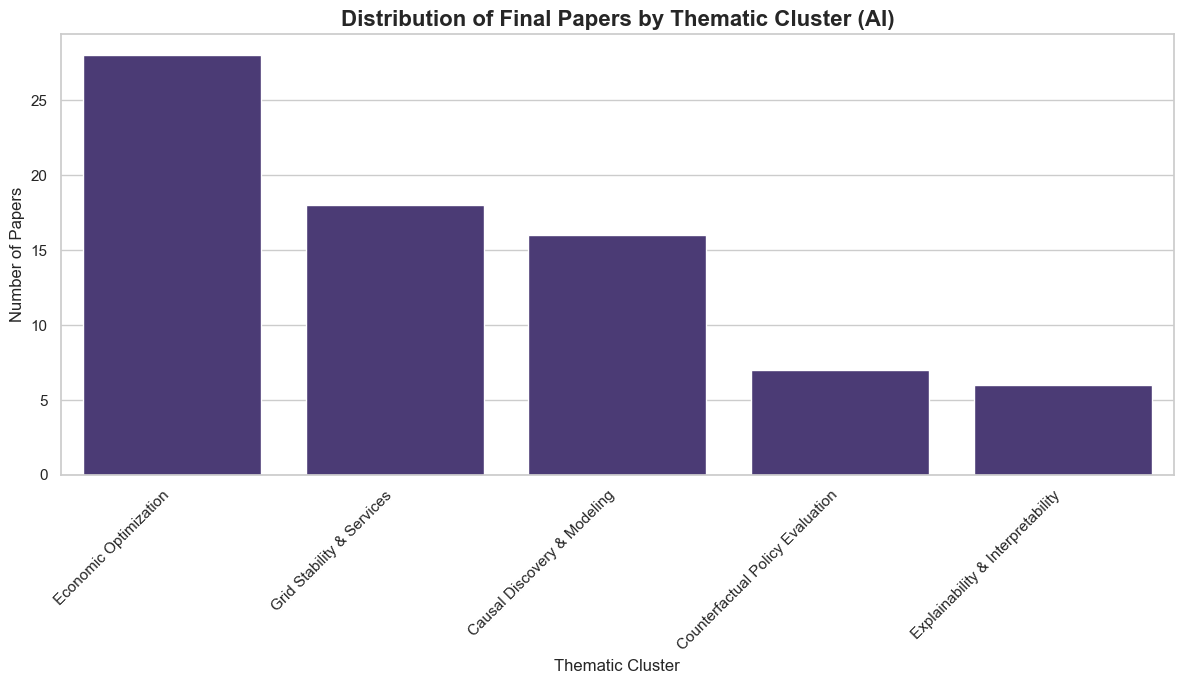

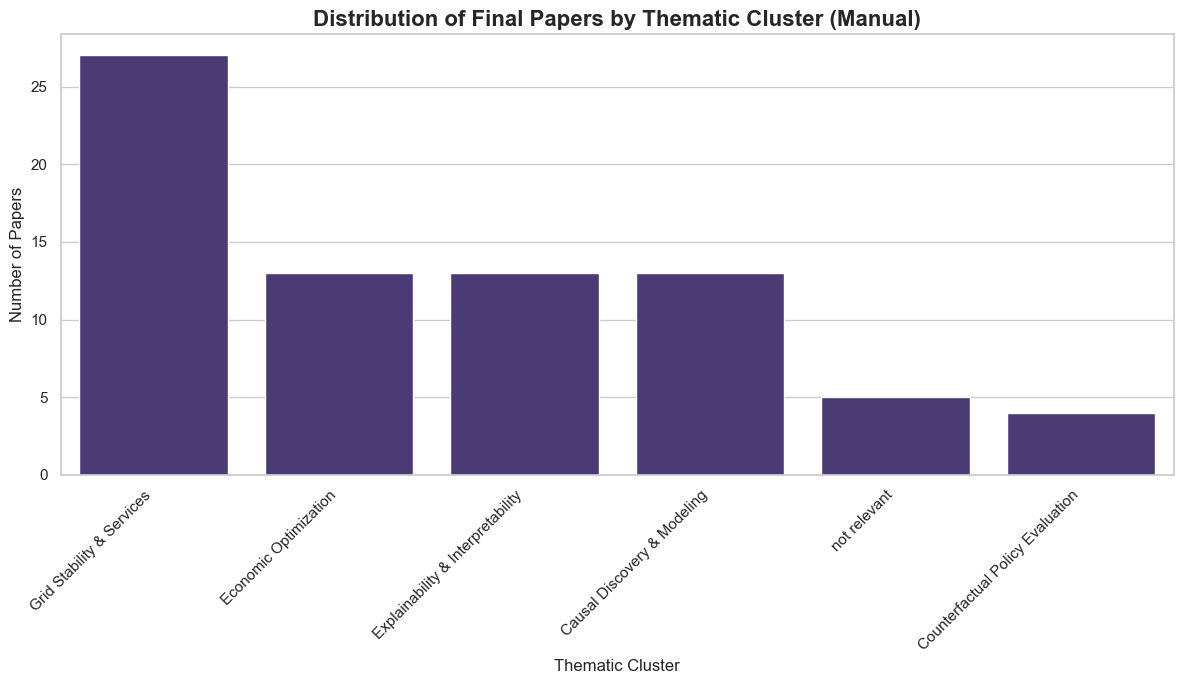

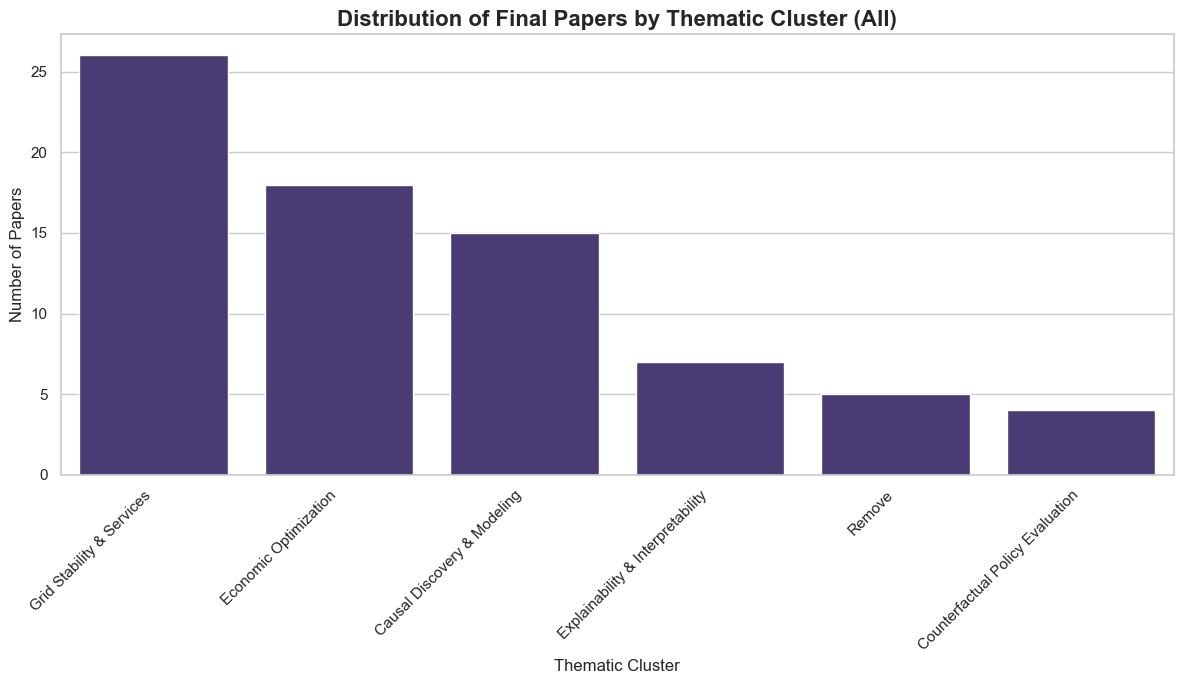

In [34]:
if not df_thematic_classification_results.empty:
    sns.set_theme(style="whitegrid", palette="viridis")

    cluster_distribution_ai = df_thematic_classification_results['AI_Cluster'].value_counts()
    cluster_distribution_manual = df_thematic_classification_results['Manual_Cluster'].value_counts()
    cluster_distribution = df_thematic_classification_results['Assigned_Cluster'].value_counts()

    print("\n--- Distribution of Papers Across Thematic Clusters ---")
    print("\n ---AI Classification: ---")
    print(cluster_distribution_ai)
    print("\n ---Manual Classification: ---")
    print(cluster_distribution_manual)
    print("\n ---Assigned Classification: ---")
    print(cluster_distribution)
    
    # It creates a high-quality bar chart for use in the final essay.
    plt.figure(figsize=(12, 7))
    sns.barplot(x=cluster_distribution_ai.index, y=cluster_distribution_ai.values)
    
    plt.title('Distribution of Final Papers by Thematic Cluster (AI)', fontsize=16, weight='bold')
    plt.xlabel('Thematic Cluster', fontsize=12)
    plt.ylabel('Number of Papers', fontsize=12)
    plt.xticks(rotation=45, ha='right') # Improves readability of labels
    plt.tight_layout() # Adjusts plot to ensure everything fits without overlapping
    plt.show()

    plt.figure(figsize=(12, 7))
    sns.barplot(x=cluster_distribution_manual.index, y=cluster_distribution_manual.values)
    plt.title('Distribution of Final Papers by Thematic Cluster (Manual)', fontsize=16, weight='bold')
    plt.xlabel('Thematic Cluster', fontsize=12)
    plt.ylabel('Number of Papers', fontsize=12)
    plt.xticks(rotation=45, ha='right') # Improves readability of labels
    plt.tight_layout() # Adjusts plot to ensure everything fits without overlapping
    plt.show()

    plt.figure(figsize=(12, 7))
    sns.barplot(x=cluster_distribution.index, y=cluster_distribution.values)
    plt.title('Distribution of Final Papers by Thematic Cluster (All)', fontsize=16, weight='bold')
    plt.xlabel('Thematic Cluster', fontsize=12)
    plt.ylabel('Number of Papers', fontsize=12)
    plt.xticks(rotation=45, ha='right') # Improves readability of labels
    plt.tight_layout() # Adjusts plot to ensure everything fits without overlapping
    plt.show()
